[*********************100%***********************]  1 of 1 completed

First few rows of data:
Price           Close       High        Low       Open   Volume
Ticker            LUV        LUV        LUV        LUV      LUV
Date                                                           
2016-01-04  38.121006  38.329962  37.412371  37.884795  5916400
2016-01-05  38.575272  39.138549  37.639509  38.520763  9364100
2016-01-06  38.929585  39.520116  37.975651  38.130100  6236500
2016-01-07  38.111923  39.202134  37.757606  39.020432  8545600
2016-01-08  38.348145  39.120379  38.257295  38.529847  7459400

Columns in DataFrame: MultiIndex([( 'Close', 'LUV'),
            (  'High', 'LUV'),
            (   'Low', 'LUV'),
            (  'Open', 'LUV'),
            ('Volume', 'LUV')],
           names=['Price', 'Ticker'])

DataFrame has MultiIndex columns.

Adjusted column names: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

'Open' and 'Close' columns are present in the DataFrame.
Length of X: 2012
Length of y: 2012


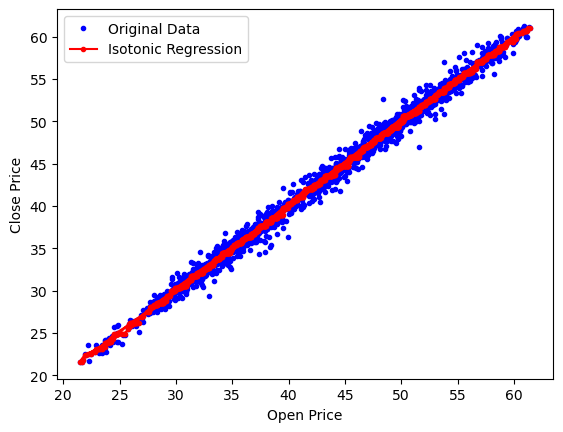

In [2]:
import pandas as pd
import yfinance
import numpy as np
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression

# Download stock data
stock_symbol = "LUV"
start_date = "2016-01-01"
end_date = "2024-01-01"

dataframe = yfinance.download(tickers=stock_symbol,
                              start=start_date,
                              end=end_date)

# Print the first few rows to inspect the structure of the data
print("First few rows of data:")
print(dataframe.head())

# Print the column names to verify how they are structured
print("\nColumns in DataFrame:", dataframe.columns)

# Check if the DataFrame has a MultiIndex (i.e., multiple levels in columns)
if isinstance(dataframe.columns, pd.MultiIndex):
    print("\nDataFrame has MultiIndex columns.")
    # Extract the first level of the MultiIndex (the 'Price' level)
    dataframe.columns = dataframe.columns.get_level_values(0)
else:
    print("\nDataFrame has single-level columns.")

# Check the column names after flattening
print("\nAdjusted column names:", dataframe.columns)

# Check if 'Open' and 'Close' columns exist after flattening
if 'Open' in dataframe.columns and 'Close' in dataframe.columns:
    print("\n'Open' and 'Close' columns are present in the DataFrame.")
else:
    print("\n'Open' and 'Close' columns are STILL NOT found in the DataFrame!")

# Drop rows with NaN values in the 'Open' and 'Close' columns
dataframe.dropna(subset=["Open", "Close"], inplace=True)

# Extract Open and Close columns
X = np.array(dataframe["Open"].values)
y = np.array(dataframe["Close"].values)

# Ensure they have the same length
print(f"Length of X: {len(X)}")
print(f"Length of y: {len(y)}")

# Fit the model
model = IsotonicRegression()
model_results = model.fit_transform(X, y)

# Plot the results
plt.plot(X, y, "b.", label="Original Data")
plt.plot(X, model_results, "r.-", label="Isotonic Regression")
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [3]:
model.score(X, y)

0.9942858181796644

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

y_train.shape

(1609,)

In [10]:
model.fit(X_train, y_train)

IsotonicRegression()

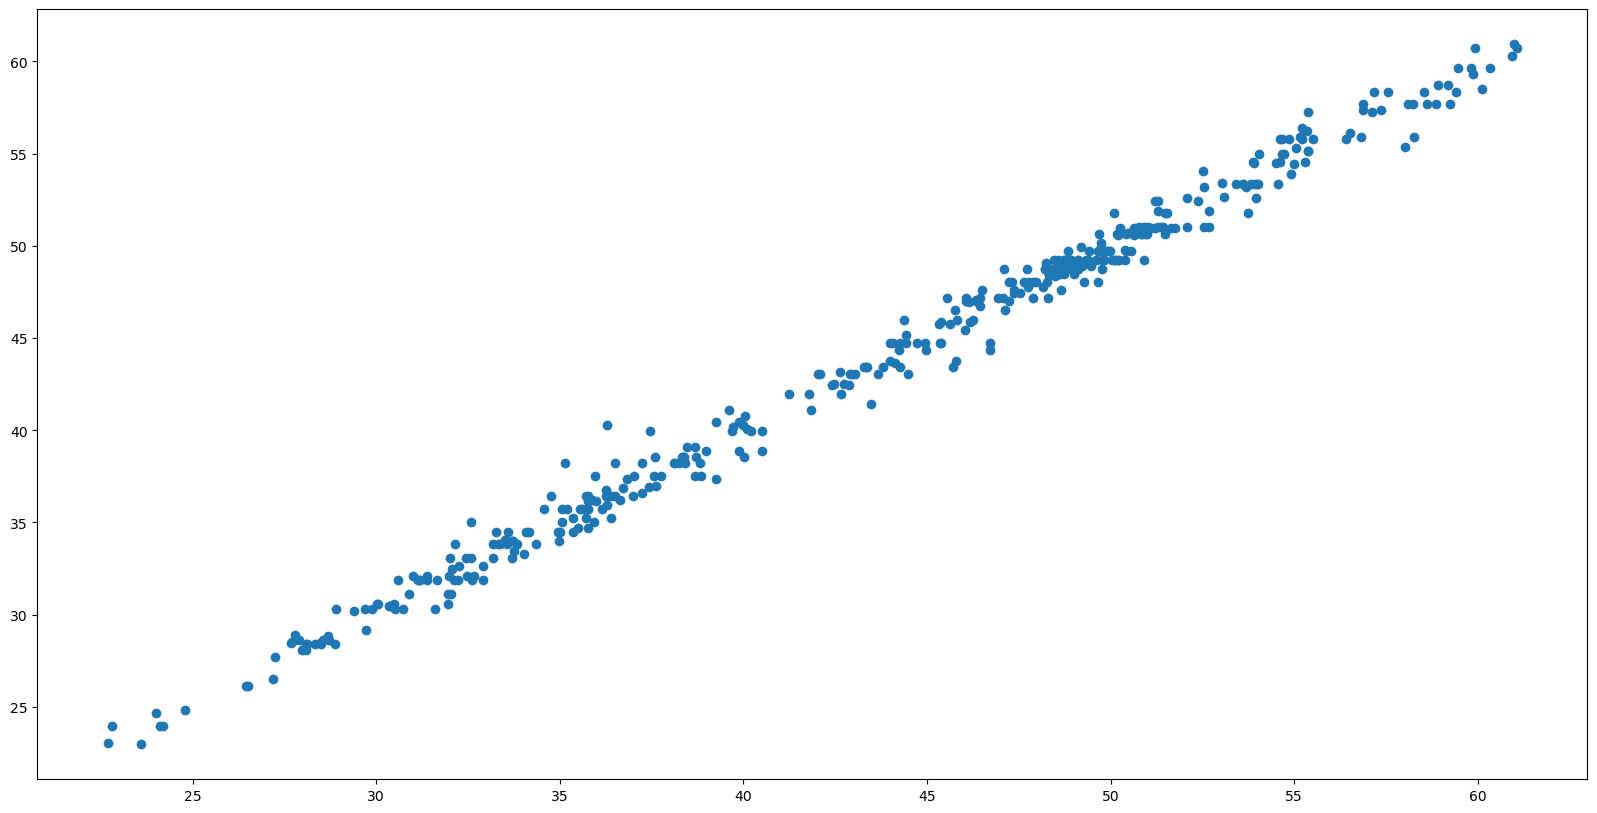

In [14]:
model_y = model.predict(X_test)

plt.figure(figsize = (20, 10))

plt.scatter(y_test, model_y)